In [2]:
# Import libraries needed for analysis
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import glob

In [3]:
# Install the SAFE Toolbox 
!pip install safepython
import safepython

In [4]:
# Import necessary libraraies from the SAFE Toolbox 
from __future__ import division, absolute_import, print_function

import sys
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatRangeSlider, IntRangeSlider
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore') # to hide warning messages
# Module to perform PAWN:
import safepython.PAWN as PAWN
# Module to visualize the results:
import safepython.plot_functions as pf
# Module to execute the model
from safepython.model_execution import model_execution
# Functions to perform the input sampling
from safepython.sampling import AAT_sampling, AAT_sampling_extend
from safepython.util import below, aggregate_boot

In [6]:
directory = "./"
file_paths_params = glob.glob(os.path.join(directory, "params*"))
file_paths_outputs = glob.glob(os.path.join(directory, "output*"))

In [19]:
# Load parameter sets into a NumPy array
params_list = [np.loadtxt(file, delimiter=',') for file in file_paths_params]
X = np.column_stack(params_list)  # Stack columns

# Define the column order
columns = ['wind_height', 'year', 'timestep', 'pc', 'alpha', 'HH','ID']

print(X[:,0])  

# Load model outputs into a NumPy array
outputs_list = [np.loadtxt(file, delimiter=',') for file in file_paths_outputs]
Y = np.column_stack(outputs_list)  # Stack columns
print(Y[0,:])

[0.00000000e+00 2.01400000e+03 1.00000000e+00 1.10000000e+01
 5.43819083e-02 9.62555091e+01 1.02318000e+05]
[0.61786059 0.68692878 0.70220374 0.73578099 0.72933556 0.41190758
 0.64498431 0.61568353 0.59068635 0.65523134 0.67658011 0.61761107
 0.69971063 0.5161874  0.59398676 0.39945992 0.67984133 0.7415932
 0.73550372 0.56041757 0.60141608 0.55264658 0.624273   0.69445313
 0.6938734  0.41570776 0.68614037 0.61137649 0.73179402 0.54092432
 0.73118997 0.68484234 0.70831272 0.64586575 0.5316326  0.58842781
 0.45668179 0.67927249 0.63242912 0.74622138 0.52387199 0.58287761
 0.69550955 0.62641166 0.69862598 0.6814505  0.51333523 0.75266027
 0.5803837  0.69008575 0.50731785 0.57522805 0.65131762 0.69013661
 0.75298099 0.50680174 0.56871874 0.65077662 0.49588613 0.59640328
 0.60385006 0.51908266 0.54734981 0.58324725 0.56750575 0.52372397
 0.64693383 0.67371286 0.56260854 0.69913386 0.50543502 0.65200519
 0.63860756 0.63848796 0.5323071  0.47920807 0.5967795  0.583797
 0.66600354 0.56293597 0

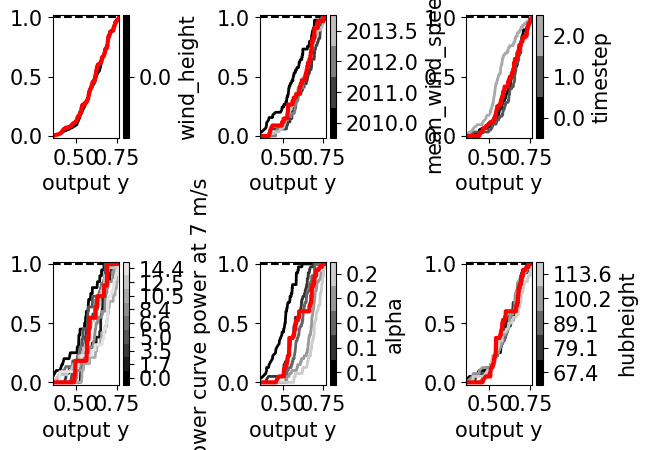

In [26]:
n = [2, 4, 4, 9, 5, 5] # number of conditioning intervals
X_Labels = ['wind_height', 'mean_wind_speed','timestep','power curve power at 7 m/s', 'alpha', 'hubheight']
# # Compute and plot conditional and unconditional CDFs:
# YF, FU, FC, xc = PAWN.pawn_plot_cdf(X, Y, n)
# plt.show()
# # Add colorbar:
# YF, FU, FC, xc = PAWN.pawn_plot_cdf(X, Y, n, cbar=True, n_col=3)
# plt.show()
# Add label to the colorbar:
YF, FU, FC, xc = PAWN.pawn_plot_cdf(X[:6,:].T, Y[0,:], n, cbar=True, n_col=3, labelinput=X_Labels)
# You can also adjust the spacing between the subplots to create a nice figure
# using the function subplots_adjust:
plt.subplots_adjust(left=None, bottom=None, right=None, top=None,
                    hspace=1, wspace=1.5)
plt.show()

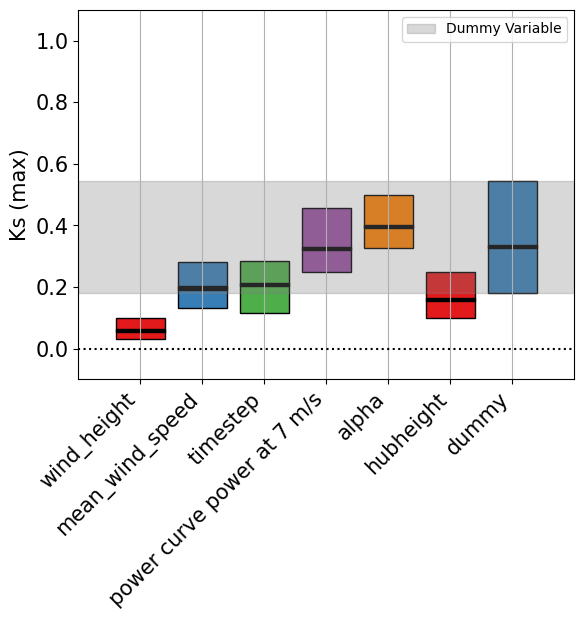

In [27]:
Nboot = 1000
# Compute sensitivity indices for Nboot bootstrap resamples
# (Warning: the following line may take some time to run, as the computation of
# CDFs is costly):
KS_median, KS_mean, KS_max, KS_dummy = PAWN.pawn_indices(X[:6,:].T, Y[0,:], n, Nboot=Nboot, dummy = True)
KS_med = np.column_stack((KS_median, KS_dummy))
# KS_median and KS_mean and KS_max have shape (Nboot, M)
# Compute mean and confidence intervals of the sensitivity indices across the
# bootstrap resamples:
KS_max_m, KS_max_lb, KS_max_ub = aggregate_boot(KS_med) # shape (M,)
X_Labels = ['wind_height', 'mean_wind_speed','timestep','power curve power at 7 m/s', 'alpha', 'hubheight', 'dummy']
# Plot bootstrapping results:


plt.figure()

# Plot the boxplot
pf.boxplot1(KS_max_m, S_lb=KS_max_lb, S_ub=KS_max_ub, 
            X_Labels=X_Labels, Y_Label='Ks (max)')

# Add shading between KS_max_lb[7] and KS_max_ub[7]
plt.axhspan(KS_max_lb[6], KS_max_ub[6], color='gray', alpha=0.3, label="Dummy Variable")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45, ha='right')

# Add legend (optional)
plt.legend()

plt.show()